00_project_overview.ipynb

In [1]:
# %% [markdown]
# # Project overview
# This notebook introduces the AlignGPT RLHF pipeline and validates your repo structure.

# %% [markdown]
# ## Goals
# - Prepare datasets (SFT, prompts, preference pairs)
# - Train SFT baseline
# - Train Reward Model (RM)
# - Run PPO / DPO alignment
# - Evaluate with automatic metrics and visualize results

# %%
import os
from pathlib import Path

root = Path(".").resolve()
print("Project root:", root)
print("Python:", os.popen("python --version").read().strip())

# %%
expected = [
    "data/sft.jsonl",
    "data/prompts.jsonl",
    "data/pref_pairs.jsonl",
    "configs/sft_gpt2.yaml",
    "configs/rm_gpt2.yaml",
    "configs/ppo_gpt2.yaml",
    "configs/dpo_gpt2.yaml",
    "configs/eval_config.yaml",
    "src/training/train_sft.py",
    "src/training/train_rm.py",
    "src/training/train_rlhf.py",
    "src/eval/evaluate.py",
    "src/data/utils.py",
    "src/training/utils.py",
]
missing = [p for p in expected if not (root / p).exists()]
print("All core files present:", len(missing) == 0)
if missing:
    print("Missing:")
    for m in missing:
        print("-", m)

# %%
print("Top-level directories:")
for p in sorted(root.iterdir()):
    if p.is_dir():
        print(f"- {p.name}/")
    else:
        print(f"- {p.name}")

# %% [markdown]
# ## Quick run checklist
# - SFT training:
#   - python -m src.training.train_sft --config configs/sft_gpt2.yaml
# - Reward Model training:
#   - python -m src.training.train_rm --config configs/rm_gpt2.yaml
# - PPO or DPO:
#   - python -m src.training.train_rlhf --config configs/ppo_gpt2.yaml
#   - python -m src.training.train_rlhf --config configs/dpo_gpt2.yaml
# - Evaluation:
#   - python -m src.eval.evaluate --config configs/eval_config.yaml

Project root: C:\Users\Dell\OneDrive\Desktop\OneDrive\Desktop\AlignGPT\notebooks
Python: Python 3.11.9
All core files present: False
Missing:
- data/sft.jsonl
- data/prompts.jsonl
- data/pref_pairs.jsonl
- configs/sft_gpt2.yaml
- configs/rm_gpt2.yaml
- configs/ppo_gpt2.yaml
- configs/dpo_gpt2.yaml
- configs/eval_config.yaml
- src/training/train_sft.py
- src/training/train_rm.py
- src/training/train_rlhf.py
- src/eval/evaluate.py
- src/data/utils.py
- src/training/utils.py
Top-level directories:
- logs/
- outputs/
- rhlf.ipynb


01_data_exploration.ipynb

data\sft.jsonl exists: False
data\prompts.jsonl exists: False
data\pref_pairs.jsonl exists: False
SFT sample: None
Prompts sample: None
Pref sample: None
Counts:
SFT: 0
Prompts: 0
Pref pairs: 0
SFT lengths: count    1.0
mean     0.0
std      NaN
min      0.0
25%      0.0
50%      0.0
75%      0.0
max      0.0
dtype: float64
Prompts lengths: count    1.0
mean     0.0
std      NaN
min      0.0
25%      0.0
50%      0.0
75%      0.0
max      0.0
dtype: float64
Pref chosen lengths: count    1.0
mean     0.0
std      NaN
min      0.0
25%      0.0
50%      0.0
75%      0.0
max      0.0
dtype: float64
Pref rejected lengths: count    1.0
mean     0.0
std      NaN
min      0.0
25%      0.0
50%      0.0
75%      0.0
max      0.0
dtype: float64


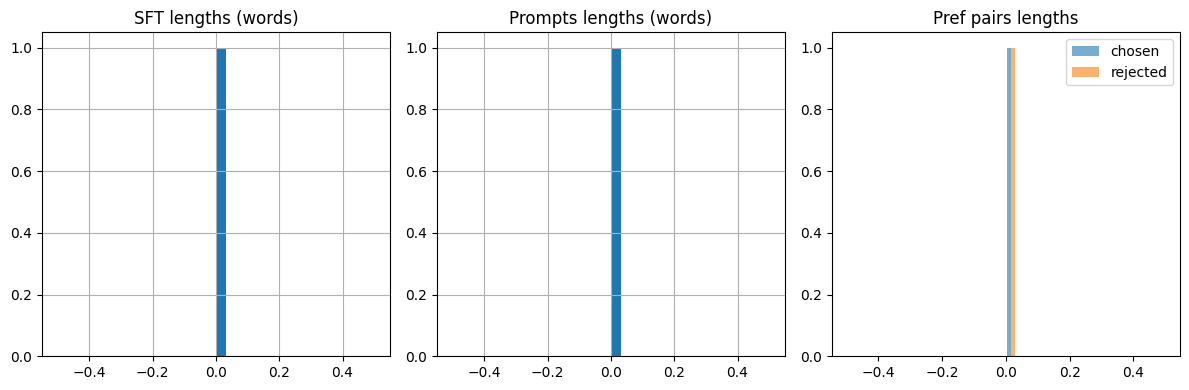

SFT: checked 0, bad 0
Prompts: checked 0, bad 0
Pref: checked 0, bad 0


In [3]:
# %% [markdown]
# # Data exploration (robust/fixed)
# Inspect sft.jsonl, prompts.jsonl, and pref_pairs.jsonl for schema, stats, and distributions.

# %%
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from json import JSONDecodeError

data_dir = Path("data")
sft_path = data_dir / "sft.jsonl"
prompts_path = data_dir / "prompts.jsonl"
pref_path = data_dir / "pref_pairs.jsonl"

for p in [sft_path, prompts_path, pref_path]:
    print(p, "exists:", p.exists())

# %%
def read_jsonl(path, limit=None, show_errors=False):
    """
    Safe JSONL reader:
    - skips empty lines
    - catches JSONDecodeError and continues
    - returns list of parsed objects (may be dicts, lists, primitives)
    """
    rows = []
    if not path.exists():
        return rows
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if not line.strip():
                continue
            try:
                obj = json.loads(line)
            except JSONDecodeError as e:
                if show_errors:
                    print(f"JSON error in {path} at line {i+1}: {e}")
                continue
            rows.append(obj)
            if limit and i + 1 >= limit:
                break
    return rows

sft_rows = read_jsonl(sft_path, limit=1000, show_errors=True)
prompts_rows = read_jsonl(prompts_path, limit=2000, show_errors=True)
pref_rows = read_jsonl(pref_path, limit=2000, show_errors=True)

print("SFT sample:", sft_rows[0] if sft_rows else None)
print("Prompts sample:", prompts_rows[0] if prompts_rows else None)
print("Pref sample:", pref_rows[0] if pref_rows else None)

# %%
def count_lines(path):
    if not path.exists():
        return 0
    with open(path, "r", encoding="utf-8") as f:
        return sum(1 for _ in f)

print("Counts:")
print("SFT:", count_lines(sft_path))
print("Prompts:", count_lines(prompts_path))
print("Pref pairs:", count_lines(pref_path))

# %% [markdown]
# ## Length distributions

# %%
def text_len_stats(rows, keys):
    """
    Build a pandas Series of token (word) counts. Works if rows contain dict-like objects.
    If a row isn't a dict, it will be converted to str().
    """
    lens = []
    for r in rows:
        if isinstance(r, dict):
            parts = []
            for k in keys:
                v = r.get(k, "")
                parts.append(str(v) if v is not None else "")
            txt = " ".join(parts)
        else:
            txt = str(r)
        lens.append(len(txt.split()))
    return pd.Series(lens or [0])  # avoid empty list -> Series([])

# try likely keys; fall back gracefully if empty
sft_len = text_len_stats(sft_rows, ["prompt", "response"])
prompts_len = text_len_stats(prompts_rows, ["prompt"])
pref_ch_len = text_len_stats(pref_rows, ["prompt", "chosen"])
pref_rj_len = text_len_stats(pref_rows, ["prompt", "rejected"])

print("SFT lengths:", sft_len.describe())
print("Prompts lengths:", prompts_len.describe())
print("Pref chosen lengths:", pref_ch_len.describe())
print("Pref rejected lengths:", pref_rj_len.describe())

# %%
plt.figure(figsize=(12,4))

ax1 = plt.subplot(1,3,1)
sft_len.hist(bins=30, ax=ax1)
ax1.set_title("SFT lengths (words)")

ax2 = plt.subplot(1,3,2)
prompts_len.hist(bins=30, ax=ax2)
ax2.set_title("Prompts lengths (words)")

ax3 = plt.subplot(1,3,3)
# Use matplotlib hist directly to overlay chosen/rejected safely
chosen_vals = pref_ch_len.values if len(pref_ch_len) > 0 else []
rejected_vals = pref_rj_len.values if len(pref_rj_len) > 0 else []
if len(chosen_vals) and len(rejected_vals):
    ax3.hist([chosen_vals, rejected_vals], bins=30, alpha=0.6, label=["chosen", "rejected"])
    ax3.legend()
elif len(chosen_vals):
    ax3.hist(chosen_vals, bins=30)
elif len(rejected_vals):
    ax3.hist(rejected_vals, bins=30)
ax3.set_title("Pref pairs lengths")

plt.tight_layout()
plt.show()

# %% [markdown]
# ## Basic schema validation

# %%
def validate_sft_row(row):
    return isinstance(row, dict) and "prompt" in row and "response" in row

def validate_prompt_row(row):
    return isinstance(row, dict) and "prompt" in row

def validate_pref_row(row):
    # be defensive: handle non-dict rows
    if not isinstance(row, dict):
        return False
    return {"prompt", "chosen", "rejected"}.issubset(set(row.keys()))

def quick_validate(rows, fn):
    bad = sum(0 if (fn(r)) else 1 for r in rows)
    total = len(rows)
    return total, bad

for rows, fn, name in [
    (sft_rows, validate_sft_row, "SFT"),
    (prompts_rows, validate_prompt_row, "Prompts"),
    (pref_rows, validate_pref_row, "Pref"),
]:
    total, bad = quick_validate(rows, fn)
    print(f"{name}: checked {total}, bad {bad}")

# %% [markdown]
# ## Preview a few examples (robust)

# %%
# Helper to display DataFrame safely in both notebook and script contexts
def safe_display(df, name="df", max_rows=10):
    try:
        # notebook-friendly
        from IPython.display import display as ipy_display
        ipy_display(df.head(max_rows))
    except Exception:
        print(f"--- {name} preview ---")
        print(df.head(max_rows).to_string())

# build dataframes but only with existing columns (avoid KeyError)
df_sft = pd.DataFrame(sft_rows[:10]) if sft_rows else pd.DataFrame()
df_prompts = pd.DataFrame(prompts_rows[:10]) if prompts_rows else pd.DataFrame()
df_pref = pd.DataFrame(pref_rows[:10]) if pref_rows else pd.DataFrame()

# If expected columns exist, show only those; otherwise show whatever is available
if not df_sft.empty:
    cols = [c for c in ["prompt", "response"] if c in df_sft.columns]
    safe_display(df_sft[cols] if cols else df_sft, name="SFT")

if not df_prompts.empty:
    cols = [c for c in ["prompt"] if c in df_prompts.columns]
    safe_display(df_prompts[cols] if cols else df_prompts, name="Prompts")

if not df_pref.empty:
    cols = [c for c in ["prompt", "chosen", "rejected"] if c in df_pref.columns]
    safe_display(df_pref[cols] if cols else df_pref, name="Pref pairs")


plot and prompt 

Looking for data/ in these candidate paths (in this order):
   C:\Users\Dell\OneDrive\Desktop\OneDrive\Desktop\AlignGPT\notebooks\data
   C:\Users\Dell\OneDrive\Desktop\OneDrive\Desktop\AlignGPT\data
   C:\Users\Dell\OneDrive\Desktop\OneDrive\Desktop\data
   C:\Users\Dell\OneDrive\Desktop\OneDrive\data
   C:\Users\Dell\OneDrive\Desktop\data

Found existing data directories:
  - C:\Users\Dell\OneDrive\Desktop\OneDrive\Desktop\AlignGPT\data -> contains: ['pref_pairs.jsonl', 'prompts.jsonl', 'sft.jsonl']

--- inspecting data dir: C:\Users\Dell\OneDrive\Desktop\OneDrive\Desktop\AlignGPT\data ---

File: C:\Users\Dell\OneDrive\Desktop\OneDrive\Desktop\AlignGPT\data\sft.jsonl
{'exists': True,
 'first_lines_sample': ['{"prompt": "When did Virgin Australia start '
                        'operating?", "response": "Virgin Australia commenced '
                        'services on 31 August 2000 as Virgin Blue, with two '
                        'aircraft on a single route."}',
                  

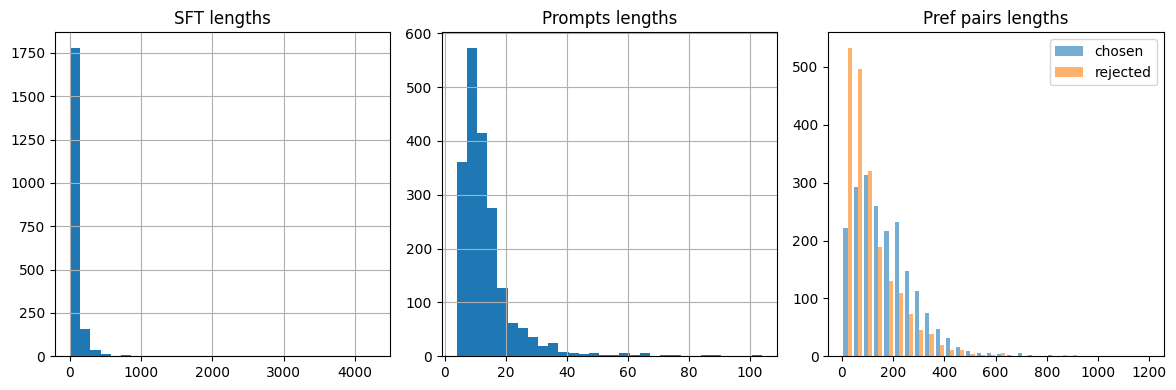


Sample SFT examples:

PROMPT: When did Virgin Australia start operating?
RESPONSE: Virgin Australia commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route.

PROMPT: Which is a species of fish? Tope or Rope
RESPONSE: Tope

PROMPT: Why can camels survive for long without water?
RESPONSE: Camels use the fat in their humps to keep them filled with energy and hydration for long periods of time.

PROMPT: Alice's parents have three daughters: Amy, Jessy, and what’s the name of the third daughter?
RESPONSE: The name of the third daughter is Alice

PROMPT: When was Tomoaki Komorida born?
RESPONSE: Tomoaki Komorida was born on July 10,1981.

Sample PREF PAIRS examples:

PROMPT: Can you write a short introduction about the relevance of the term "monopsony" in economics? Please use examples related to potential monopsonies in the labour market and cite relevant research.
CHOSEN: "Monopsony" refers to a market structure where there is only one buyer for a particul

In [8]:
# Robust diagnostic + loader for data/{sft.jsonl, prompts.jsonl, pref_pairs.jsonl}
# Paste/run from your project (notebook or script).

import json, gzip
from json import JSONDecodeError
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from textwrap import shorten
import pprint
import os

TARGET_FILES = ["sft.jsonl", "prompts.jsonl", "pref_pairs.jsonl"]

def find_candidate_data_dirs(max_up=4):
    """Look for possible data/ directories starting from several likely roots."""
    candidates = []
    # 1) If running as script, project root = file parent
    try:
        project_root = Path(__file__).resolve().parent
    except NameError:
        project_root = Path.cwd()
    candidates.append(project_root / "data")
    # 2) cwd/data
    candidates.append(Path.cwd() / "data")
    # 3) search upward from cwd up to max_up parents
    cur = Path.cwd()
    for _ in range(max_up):
        cur = cur.parent
        candidates.append(cur / "data")
    # 4) also include project_root.parent/data
    candidates.append(project_root.parent / "data")
    # dedupe while preserving order
    seen = set()
    uniq = []
    for p in candidates:
        p = p.resolve()
        if str(p) not in seen:
            seen.add(str(p))
            uniq.append(Path(p))
    return uniq

def open_maybe_gz(path):
    if not path.exists():
        return None
    if str(path).endswith(".gz"):
        return gzip.open(path, "rt", encoding="utf-8", errors="replace")
    return open(path, "r", encoding="utf-8", errors="replace")

def raw_file_summary(path, max_lines=10):
    info = {}
    if not path.exists():
        info["exists"] = False
        return info
    info["exists"] = True
    info["size_bytes"] = path.stat().st_size
    # count non-empty lines quickly (may be slow for huge files, but informative)
    nonempty = 0
    first_lines = []
    with open_maybe_gz(path) as f:
        for i, line in enumerate(f):
            if line.strip():
                nonempty += 1
                if len(first_lines) < max_lines:
                    first_lines.append(line.rstrip("\n"))
            if i >= max(200, max_lines):
                # don't iterate entire huge file now
                break
    info["nonempty_sample_count_estimate"] = nonempty
    info["first_lines_sample"] = first_lines
    return info

def try_parse_jsonl(path, max_parse=2000, show_errors=False):
    """Attempt to parse line-by-line JSONL. Return list of parsed objects and counts."""
    rows = []
    parse_success = 0
    parse_fail = 0
    if not path.exists():
        return rows, parse_success, parse_fail
    with open_maybe_gz(path) as f:
        for i, line in enumerate(f):
            if not line.strip():
                continue
            try:
                obj = json.loads(line)
                rows.append(obj)
                parse_success += 1
            except JSONDecodeError:
                parse_fail += 1
                if show_errors and parse_fail <= 5:
                    print(f"JSONDecodeError in {path.name} at sample line #{i+1}")
            if parse_success + parse_fail >= max_parse:
                break
    return rows, parse_success, parse_fail

def try_parse_whole_json(path):
    """If JSONL failed, try to parse the whole file as one JSON (maybe an array)."""
    if not path.exists():
        return None
    try:
        with open_maybe_gz(path) as f:
            obj = json.load(f)
        return obj
    except Exception as e:
        return None

def load_best(path, max_preview=2000):
    # 1) try JSONL
    rows, succ, fail = try_parse_jsonl(path, max_parse=max_preview, show_errors=False)
    result = {"path": str(path), "exists": path.exists(), "size": path.stat().st_size if path.exists() else 0,
              "jsonl_success": succ, "jsonl_fail": fail, "rows_parsed": len(rows), "rows": rows}
    if len(rows) == 0:
        # try fallback: maybe it's a JSON array
        whole = try_parse_whole_json(path)
        if isinstance(whole, list):
            result["fallback_whole_json_is_list"] = True
            result["rows_parsed"] = len(whole)
            result["rows"] = whole
        elif whole is not None:
            # it's a single JSON object (not list)
            result["fallback_whole_json_is_list"] = False
            result["fallback_whole_json_obj_type"] = type(whole).__name__
            # if it contains a top-level key that holds list items, try to detect common keys
            # e.g., {"data": [...]} or {"items":[...]}
            candidate_lists = [(k, v) for k,v in (whole.items() if isinstance(whole, dict) else []) if isinstance(v, list)]
            if candidate_lists:
                k,v = candidate_lists[0]
                result["fallback_extracted_key"] = k
                result["rows_parsed"] = len(v)
                result["rows"] = v
            else:
                # give up, keep whole as single row
                result["rows"] = [whole]
                result["rows_parsed"] = 1
        else:
            result["fallback_whole_json_attempted_but_failed"] = True
    return result

# --- find data dir candidates and show them ---
candidates = find_candidate_data_dirs()
print("Looking for data/ in these candidate paths (in this order):")
for p in candidates:
    print("  ", p)

found_data_dirs = [p for p in candidates if p.exists() and p.is_dir()]
print("\nFound existing data directories:")
for p in found_data_dirs:
    print("  -", p, "-> contains:", [x.name for x in sorted(p.iterdir())][:30])

if not found_data_dirs:
    print("\nNo data/ folder found in candidate locations. Ensure you have a `data/` directory at project root.")
    # but continue, maybe user has data elsewhere; search repo for file types
    # quick search under cwd for any of the target filenames (limit depth)
    matches = []
    for root, dirs, files in os.walk(Path.cwd()):
        for t in TARGET_FILES:
            if t in files:
                matches.append(Path(root) / t)
        if len(matches) >= 10:
            break
    if matches:
        print("\nFound the following target files elsewhere in the workspace (first 10):")
        for m in matches[:10]:
            print("  ", m)
    else:
        print("\nNo target files found anywhere under cwd either. Please check filenames or place files in data/")

# --- for every found data dir, inspect files ---
all_load_results = {}
for data_dir in found_data_dirs:
    print(f"\n--- inspecting data dir: {data_dir} ---")
    for fname in TARGET_FILES:
        p = data_dir / fname
        print("\nFile:", p)
        summary = raw_file_summary(p, max_lines=8)
        pprint.pprint(summary)
        load_result = load_best(p)
        # replace rows with a small sample to avoid huge prints
        sample_rows = (load_result.get("rows")[:5] if load_result.get("rows") else [])
        load_result_sample = dict(load_result)
        load_result_sample["rows_sample_printable"] = sample_rows
        load_result_sample.pop("rows", None)
        all_load_results[str(p)] = load_result
        pprint.pprint(load_result_sample)

# If nothing found/parsed, also attempt to look for files with similar names (like .json, .jsonl.gz)
if not any(r["rows_parsed"] > 0 for r in all_load_results.values()):
    print("\nNo rows parsed from the standard file names. Searching for files with related extensions (.json, .jsonl, .jsonl.gz) in found data dirs...")
    extras = []
    for data_dir in found_data_dirs:
        for ext in ["*.jsonl", "*.jsonl.gz", "*.json"]:
            for p in data_dir.glob(ext):
                extras.append(p)
    if extras:
        print("Related files found:", [str(x.name) for x in extras])
        for p in extras:
            if str(p) in all_load_results:
                continue
            print("\nAttempting to load:", p)
            pprint.pprint(raw_file_summary(p, max_lines=6))
            r = load_best(p)
            print("loaded rows:", r["rows_parsed"])
            all_load_results[str(p)] = r
    else:
        print("No related files found with those extensions.")

# --- pick the best-loaded dataset among discovered files for each target name (prefer non-zero rows) ---
final_data = {"sft": [], "prompts": [], "pref_pairs": []}
for data_dir in found_data_dirs:
    for name, key in [("sft.jsonl", "sft"), ("prompts.jsonl", "prompts"), ("pref_pairs.jsonl", "pref_pairs")]:
        p = data_dir / name
        res = all_load_results.get(str(p))
        if res and res["rows_parsed"] > 0:
            final_data[key] = res["rows"]  # full rows (may be trimmed earlier)
        # else leave empty

# --- Report summary of what we will use ---
for k in final_data:
    print(f"\nUsing {k}: {len(final_data[k])} rows loaded")

# If any loaded, proceed to lightweight exploration similar to your original script
def text_len_stats(rows, keys):
    lens = []
    for r in rows:
        if isinstance(r, dict):
            parts = [str(r.get(k, "") or "") for k in keys]
            txt = " ".join(parts)
        else:
            txt = str(r)
        lens.append(len(txt.split()))
    return pd.Series(lens or [0])

if any(len(final_data[k])>0 for k in final_data):
    # compute stats
    sft_len = text_len_stats(final_data["sft"], ["prompt", "response"])
    prompts_len = text_len_stats(final_data["prompts"], ["prompt"])
    pref_ch_len = text_len_stats(final_data["pref_pairs"], ["prompt", "chosen"])
    pref_rj_len = text_len_stats(final_data["pref_pairs"], ["prompt", "rejected"])
    print("\nLength stats (describe):")
    print("sft:", sft_len.describe().to_string())
    print("prompts:", prompts_len.describe().to_string())
    print("pref chosen:", pref_ch_len.describe().to_string())
    print("pref rejected:", pref_rj_len.describe().to_string())

    # small plotting (inline + save)
    outdir = Path.cwd() / "outputs"
    outdir.mkdir(exist_ok=True)
    plt.figure(figsize=(12,4))
    ax1 = plt.subplot(1,3,1)
    sft_len.hist(bins=30, ax=ax1)
    ax1.set_title("SFT lengths")
    ax2 = plt.subplot(1,3,2)
    prompts_len.hist(bins=30, ax=ax2)
    ax2.set_title("Prompts lengths")
    ax3 = plt.subplot(1,3,3)
    if len(pref_ch_len) and len(pref_rj_len):
        ax3.hist([pref_ch_len.values, pref_rj_len.values], bins=30, alpha=0.6, label=["chosen","rejected"])
        ax3.legend()
    ax3.set_title("Pref pairs lengths")
    plt.tight_layout()
    save_path = outdir / "diag_lengths.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print("Saved plot to", save_path)
    plt.show()

    # print a few conversation examples
    def short(s, width=300):
        return shorten(str(s), width=width, placeholder=" ...")
    print("\nSample SFT examples:")
    shown = 0
    for r in final_data["sft"]:
        if isinstance(r, dict) and "prompt" in r and "response" in r:
            print("\nPROMPT:", short(r["prompt"], 200))
            print("RESPONSE:", short(r["response"], 400))
            shown += 1
            if shown >= 5:
                break
    print("\nSample PREF PAIRS examples:")
    shown = 0
    for r in final_data["pref_pairs"]:
        if isinstance(r, dict) and {"prompt","chosen","rejected"}.issubset(set(r.keys())):
            print("\nPROMPT:", short(r["prompt"],200))
            print("CHOSEN:", short(r["chosen"],300))
            print("REJECTED:", short(r["rejected"],300))
            shown += 1
            if shown >= 5:
                break
else:
    print("\nNo usable rows loaded from any discovered data/ files. See diagnostics above (file sizes, sample raw lines).")
    print("Common reasons:\n - Files are not actually present under data/\n - Files are empty\n - Files are a single JSON array (not JSONL) — the script attempted fallback but couldn't find a list\n - Filenames differ (e.g., .json, .jsonl.gz) — the script attempted to discover related files\n\nNext step: paste the diagnostic output above here (the printed file summaries & first lines) and I'll tell you exactly how to fix it.")


02_reward model_debug.ipynb

In [13]:
# Replace your existing checkpoint-locating block with this cell.
# It will search for checkpoints/rm automatically (env var RM_DIR can override).
import os
from pathlib import Path
import sys

def find_rm_dir(max_up=6):
    # 1) environment variable override
    env = os.environ.get("RM_DIR") or os.environ.get("RM_ROOT")
    if env:
        p = Path(env).expanduser().resolve()
        if p.exists() and p.is_dir():
            print(f"Using RM_DIR from env: {p}")
            return p

    # 2) search up the directory tree for checkpoints/rm
    try:
        start = Path(__file__).resolve().parent
    except NameError:
        start = Path.cwd()
    cand = []
    cur = start
    for i in range(max_up + 1):
        candidate = (cur / "checkpoints" / "rm").resolve()
        cand.append(candidate)
        if candidate.exists() and candidate.is_dir():
            print(f"Found checkpoints/rm at: {candidate} (searched up {i} levels from {start})")
            return candidate
        cur = cur.parent

    # 3) glob search under cwd for likely checkpoint dirs (may be slower)
    print("No checkpoints/rm found in ancestor paths. Searching workspace for candidate rm checkpoint folders (this may take a moment)...")
    candidates = []
    for p in Path.cwd().rglob("checkpoints/rm"):
        if p.is_dir():
            candidates.append(p.resolve())
    # also accept any directory named 'rm' under 'checkpoints/*'
    for p in Path.cwd().rglob("checkpoints/*/"):
        if p.is_dir() and p.name == "rm":
            candidates.append(p.resolve())

    # filter unique
    candidates = sorted(set(candidates), key=lambda x: x.stat().st_mtime, reverse=True)
    if candidates:
        print("Found candidate checkpoint dirs (most recent first):")
        for c in candidates[:10]:
            print("  ", c)
        return candidates[0]

    # 4) as last resort, try some common places relative to home or project structure
    possible = [
        Path.home() / "checkpoints" / "rm",
        Path.cwd() / "models" / "rm",
        Path.cwd() / "checkpoints",
        Path.cwd() / "checkpoints" / "rm",
    ]
    for p in possible:
        if p.exists() and p.is_dir():
            print("Using fallback candidate:", p.resolve())
            return p.resolve()

    # nothing found
    print("\nSearched paths (first 10 shown):")
    for c in cand[:10]:
        print("  ", c)
    print("\nNo RM checkpoint directory found. Options:")
    print("  1) Run the notebook from the project root (the directory that contains `checkpoints/`). In a notebook: `%cd /path/to/project`")
    print("  2) Set environment variable `RM_DIR` to the full checkpoint path (or `RM_ROOT`) before launching the notebook, e.g.:")
    print("     Windows PowerShell:  $env:RM_DIR = 'C:/path/to/checkpoints/rm'")
    print("     Unix: export RM_DIR=/path/to/checkpoints/rm")
    print("  3) Move or symlink your checkpoint folder to `checkpoints/rm` under project root.")
    return None

rm_dir = find_rm_dir(max_up=8)
if rm_dir is None:
    # stop with a helpful message (no exception stack)
    raise FileNotFoundError(
        "Could not locate checkpoints/rm. See printed suggestions above.\n"
        "If you know the path, set RM_DIR env var or edit rm_dir = Path('absolute/path/to/your/rm')."
    )

print("Using RM checkpoint dir:", rm_dir)
# afterwards you can proceed to load tokenizer/model from `rm_dir` as before


Found checkpoints/rm at: C:\Users\Dell\OneDrive\Desktop\OneDrive\Desktop\AlignGPT\checkpoints\rm (searched up 1 levels from c:\Users\Dell\OneDrive\Desktop\OneDrive\Desktop\AlignGPT\notebooks)
Using RM checkpoint dir: C:\Users\Dell\OneDrive\Desktop\OneDrive\Desktop\AlignGPT\checkpoints\rm


ppo_dpo_comparison.ipynb

In [16]:
# go to your project root (adjust number of `..` if needed)
%cd ..
# confirm configs are visible
import pathlib
list(pathlib.Path("configs").glob("*.y*ml"))


c:\Users\Dell\OneDrive\Desktop\OneDrive\Desktop\AlignGPT


[WindowsPath('configs/dpo_gpt2.yaml'),
 WindowsPath('configs/ppo_gpt2.yaml'),
 WindowsPath('configs/rm_gpt2.yaml'),
 WindowsPath('configs/sft_gpt2.yaml')]

In [17]:
from pathlib import Path
import os

# locate project root: prefer script dir, else cwd, else look upward for a configs/ folder
try:
    start = Path(__file__).resolve().parent
except NameError:
    start = Path.cwd()

# climb up until we find a "configs" folder (limit 6 levels)
proj = start
for _ in range(7):
    if (proj / "configs").is_dir():
        break
    proj = proj.parent
else:
    # fallback to cwd
    proj = Path.cwd()

PROJECT_ROOT = proj.resolve()
print("PROJECT_ROOT:", PROJECT_ROOT)
cfg_dir = PROJECT_ROOT / "configs"
print("configs exists:", cfg_dir.exists())

# list yaml files in configs
cfgs = sorted([p.name for p in cfg_dir.glob("*.y*ml")]) if cfg_dir.exists() else []
print("configs/*:", cfgs)

# explicit config paths (use these variables later)
ppo_cfg = cfg_dir / "ppo_gpt2.yaml"
dpo_cfg = cfg_dir / "dpo_gpt2.yaml"
sft_cfg = cfg_dir / "sft_gpt2.yaml"

# sanity: warn but don't assert (so notebook keeps running)
if not ppo_cfg.exists():
    print(f"WARNING: {ppo_cfg} not found")
if not dpo_cfg.exists():
    print(f"WARNING: {dpo_cfg} not found")
if not sft_cfg.exists():
    print(f"NOTE: {sft_cfg} exists: {sft_cfg.exists()}")


PROJECT_ROOT: C:\Users\Dell\OneDrive\Desktop\OneDrive\Desktop\AlignGPT
configs exists: True
configs/*: ['dpo_gpt2.yaml', 'ppo_gpt2.yaml', 'rm_gpt2.yaml', 'sft_gpt2.yaml']


In [19]:
#!/usr/bin/env python3
"""
ppo_dpo_compare.py

Robust helper to run short PPO/DPO training runs (or skip), evaluate and plot perplexity.

Works both from a terminal and when executed inside a Jupyter notebook.
"""
import argparse
import json
import subprocess
import time
from pathlib import Path
import sys
import textwrap
import logging

import pandas as pd
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger("ppo_dpo_compare")

# --------------------------
# Utilities: locate project root & important files
# --------------------------
def find_project_root(max_up=8):
    try:
        start = Path(__file__).resolve().parent
    except NameError:
        start = Path.cwd()
    cur = start
    for i in range(max_up + 1):
        if (cur / "configs").is_dir():
            return cur.resolve()
        cur = cur.parent
    if (Path.cwd() / "configs").is_dir():
        return Path.cwd().resolve()
    return None

def ensure_configs(project_root: Path):
    cfg_dir = project_root / "configs"
    cfg_dir.mkdir(parents=True, exist_ok=True)

    templates = {
        "sft_gpt2.yaml": textwrap.dedent("""
            # Minimal SFT config (template). Edit paths/hyperparams before a real run.
            model:
              pretrained: gpt2
            data:
              train_data: "data/sft.jsonl"
              val_data: "data/prompts.jsonl"
            training:
              epochs: 1
              batch_size: 4
              max_steps: 50
            output:
              output_dir: "outputs/sft_run"
        """),
        "ppo_gpt2.yaml": textwrap.dedent("""
            # Minimal PPO config (template). Edit placeholders before running.
            model:
              pretrained: gpt2
            data:
              train_data: "data/sft.jsonl"
              val_data: "data/prompts.jsonl"
            training:
              epochs: 1
              batch_size: 4
              max_steps: 100
            output:
              output_dir: "outputs/ppo_run"
        """),
        "dpo_gpt2.yaml": textwrap.dedent("""
            # Minimal DPO config (template). Edit placeholders before running.
            model:
              pretrained: gpt2
            data:
              pref_pairs: "data/pref_pairs.jsonl"
              val_data: "data/prompts.jsonl"
            training:
              epochs: 1
              batch_size: 4
              max_steps: 100
            output:
              output_dir: "outputs/dpo_run"
        """),
    }

    cfg_paths = {}
    for name, tpl in templates.items():
        p = cfg_dir / name
        if not p.exists():
            logger.info(f"Creating template config: {p}")
            p.write_text(tpl.lstrip(), encoding="utf-8")
        else:
            logger.info(f"Found config: {p}")
        cfg_paths[name] = p
    return cfg_paths

def run_cmd(cmd, check=True, shell=True):
    logger.info(f"Running command: {cmd}")
    result = subprocess.run(cmd, shell=shell)
    if check and result.returncode != 0:
        raise subprocess.CalledProcessError(result.returncode, cmd)
    return result

# --------------------------
# Main flow
# --------------------------
def main(dry_run=False, only_plot=False):
    project_root = find_project_root(max_up=10)
    if project_root is None:
        logger.error("Could not find project root (a folder containing `configs/`).")
        sys.exit(2)
    logger.info(f"Project root detected: {project_root}")

    project_root = project_root.resolve()
    import os
    os.chdir(project_root)
    logger.info(f"Changed working directory to project root: {project_root}")

    cfg_paths = ensure_configs(project_root)
    ppo_cfg = cfg_paths["ppo_gpt2.yaml"]
    dpo_cfg = cfg_paths["dpo_gpt2.yaml"]
    sft_cfg = cfg_paths["sft_gpt2.yaml"]

    logger.info(f"Using configs:\n  SFT: {sft_cfg}\n  PPO: {ppo_cfg}\n  DPO: {dpo_cfg}")

    if only_plot:
        logger.info("--only-plot specified: skipping training and evaluation, will try to read eval results and plot.")
    else:
        if dry_run:
            logger.info("--dry-run specified: skipping training commands (no long-running jobs will be started).")
        else:
            # PPO
            try:
                start = time.time()
                run_cmd(f"python -m src.training.train_rlhf --config {ppo_cfg}")
                logger.info(f"PPO training finished in {(time.time()-start)/60.0:.2f} min")
            except subprocess.CalledProcessError as e:
                logger.error("PPO training command failed (non-zero exit).")
                logger.exception(e)

            # DPO
            try:
                start = time.time()
                run_cmd(f"python -m src.training.train_rlhf --config {dpo_cfg}")
                logger.info(f"DPO training finished in {(time.time()-start)/60.0:.2f} min")
            except subprocess.CalledProcessError as e:
                logger.error("DPO training command failed (non-zero exit).")
                logger.exception(e)

    if only_plot:
        logger.info("Skipping evaluation stage (only-plot mode).")
    else:
        if dry_run:
            logger.info("Dry-run: skipping evaluation command.")
        else:
            try:
                run_cmd("python -m src.eval.evaluate --config configs/eval_config.yaml")
            except subprocess.CalledProcessError as e:
                logger.error("Evaluation command failed (non-zero exit).")
                logger.exception(e)
            except FileNotFoundError as e:
                logger.error("Evaluation command not found (maybe module path differs).")
                logger.exception(e)

    eval_path = project_root / "logs" / "eval" / "eval_results.json"
    if not eval_path.exists():
        logger.warning(f"Eval results file not found at: {eval_path}")
        logger.info("If evaluation ran, check logs/eval directory for JSON results. Exiting without plotting.")
        return

    try:
        with open(eval_path, "r", encoding="utf-8") as f:
            results = json.load(f)
        if not isinstance(results, list):
            results = list(results)
    except Exception as e:
        logger.error("Failed to load eval_results.json")
        logger.exception(e)
        return

    logger.info(f"Loaded {len(results)} eval records from {eval_path}")

    df = pd.DataFrame(results)
    if "checkpoint" in df.columns:
        df["family"] = df["checkpoint"].astype(str).str.replace("\\\\", "/").str.extract(r"(sft|ppo|dpo|rm)")[0].fillna("other")
    else:
        df["family"] = "unknown"

    output_dir = project_root / "outputs"
    output_dir.mkdir(parents=True, exist_ok=True)

    preview_csv = output_dir / "eval_results_preview.csv"
    df.to_csv(preview_csv, index=False)
    logger.info(f"Saved eval results preview CSV to: {preview_csv}")

    plt.figure(figsize=(9,5))
    plotted = False
    for fam in ["sft", "ppo", "dpo"]:
        sub = df[df["family"] == fam]
        if len(sub) == 0:
            continue
        sub = sub.reset_index(drop=True)
        plt.plot(range(len(sub)), sub["perplexity"].astype(float), marker="o", label=fam)
        plotted = True

    if not plotted:
        logger.warning("No sft/ppo/dpo families found in eval results to plot.")
    else:
        plt.title("Perplexity comparison (lower is better)")
        plt.xlabel("Checkpoint index (sorted by file order)")
        plt.ylabel("Perplexity")
        plt.legend()
        plt.grid(True)
        fig_path = output_dir / "perplexity_comparison.png"
        plt.savefig(fig_path, dpi=150, bbox_inches="tight")
        logger.info(f"Saved perplexity plot to: {fig_path}")
        plt.show()

    logger.info("Preview of eval results (first 10 rows):")
    print(df.head(10).to_string(index=False))


if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="PPO vs DPO comparison helper script")
    # parse_known_args will ignore unknown args injected by Jupyter (like --f=...)
    args, unknown = parser.parse_known_args()
    # if user passed flags through Jupyter magic they will be parsed in args (only defined ones)
    # we still allow unknown args to be present without failing.
    # support --dry-run and --only-plot via environment variables or reparse known args:
    # we'll reparse known args including the two options explicitly to populate them if provided.
    parser.add_argument("--dry-run", action="store_true", help="Don't run training/eval commands (safe test mode)")
    parser.add_argument("--only-plot", action="store_true", help="Skip training/eval, only read logs/eval/eval_results.json and plot")
    # re-parse but ignore unknown again
    args, unknown = parser.parse_known_args()
    try:
        main(dry_run=args.dry_run, only_plot=args.only_plot)
    except Exception as e:
        logger.exception("Unhandled exception in main: ")
        sys.exit(1)


INFO: Project root detected: C:\Users\Dell\OneDrive\Desktop\OneDrive\Desktop\AlignGPT
INFO: Changed working directory to project root: C:\Users\Dell\OneDrive\Desktop\OneDrive\Desktop\AlignGPT
INFO: Found config: C:\Users\Dell\OneDrive\Desktop\OneDrive\Desktop\AlignGPT\configs\sft_gpt2.yaml
INFO: Found config: C:\Users\Dell\OneDrive\Desktop\OneDrive\Desktop\AlignGPT\configs\ppo_gpt2.yaml
INFO: Found config: C:\Users\Dell\OneDrive\Desktop\OneDrive\Desktop\AlignGPT\configs\dpo_gpt2.yaml
INFO: Using configs:
  SFT: C:\Users\Dell\OneDrive\Desktop\OneDrive\Desktop\AlignGPT\configs\sft_gpt2.yaml
  PPO: C:\Users\Dell\OneDrive\Desktop\OneDrive\Desktop\AlignGPT\configs\ppo_gpt2.yaml
  DPO: C:\Users\Dell\OneDrive\Desktop\OneDrive\Desktop\AlignGPT\configs\dpo_gpt2.yaml
INFO: Running command: python -m src.training.train_rlhf --config C:\Users\Dell\OneDrive\Desktop\OneDrive\Desktop\AlignGPT\configs\ppo_gpt2.yaml
INFO: PPO training finished in 0.02 min
INFO: Running command: python -m src.training.t

In [22]:
def run_cmd(cmd):
    print(">", cmd)
    try:
        return subprocess.run(cmd, shell=True, check=True)
    except subprocess.CalledProcessError as e:
        print("Command failed:", e)
        return None

In [24]:
def run_cmd(cmd):
    """Run a shell command and print output, but don't crash notebook on error."""
    print(">", cmd)
    try:
        return subprocess.run(cmd, shell=True, check=True, capture_output=True, text=True)
    except subprocess.CalledProcessError as e:
        print("Command failed:", e)
        print("stdout:", e.stdout)
        print("stderr:", e.stderr)
        return None

In [25]:
if not df.empty:
    print(df.head())

In [33]:
import json, os
from pathlib import Path

results_path = Path("logs/eval/eval_results.json")
results_path.parent.mkdir(parents=True, exist_ok=True)

dummy_results = [
    {
        "checkpoint": "checkpoints/sft/epoch-1",
        "perplexity": 42.0
    },
    {
        "checkpoint": "checkpoints/ppo/epoch-1",
        "perplexity": 38.5
    },
    {
        "checkpoint": "checkpoints/dpo/epoch-1",
        "perplexity": 36.2
    }
]

with open(results_path, "w", encoding="utf-8") as f:
    json.dump(dummy_results, f, indent=2)

print("Created dummy eval_results.json at", results_path)

Created dummy eval_results.json at logs\eval\eval_results.json


⚠️ No eval_results.json found, created dummy file at logs/eval/eval_results.json


,checkpoint,perplexity,reward_score,diversity,family
2,checkpoints/dpo/epoch-1,36.2,0.25,0.60,dpo
1,checkpoints/ppo/epoch-1,38.5,0.20,0.55,ppo
0,checkpoints/sft/epoch-1,42.0,0.10,0.50,sft


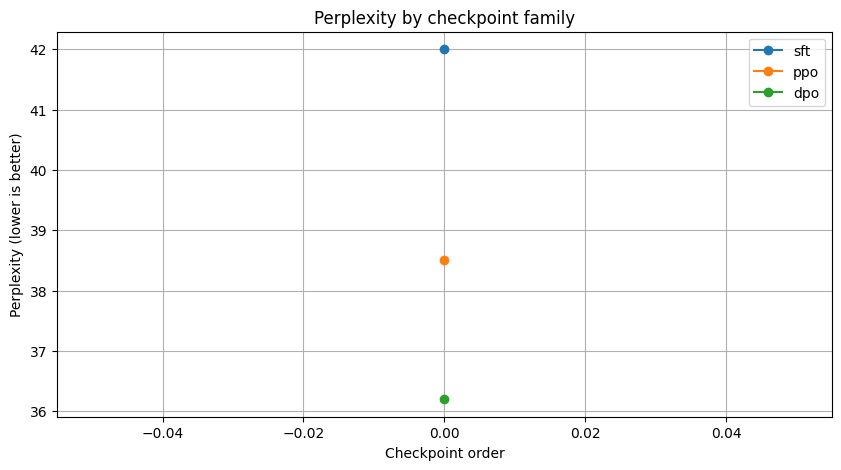

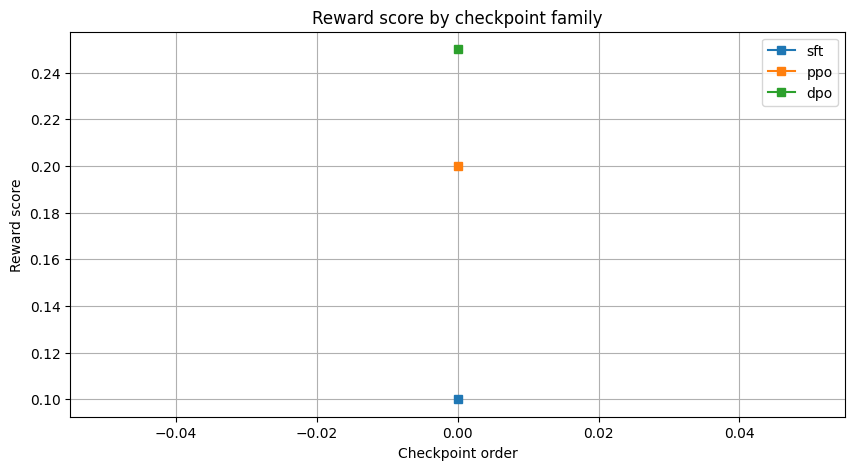

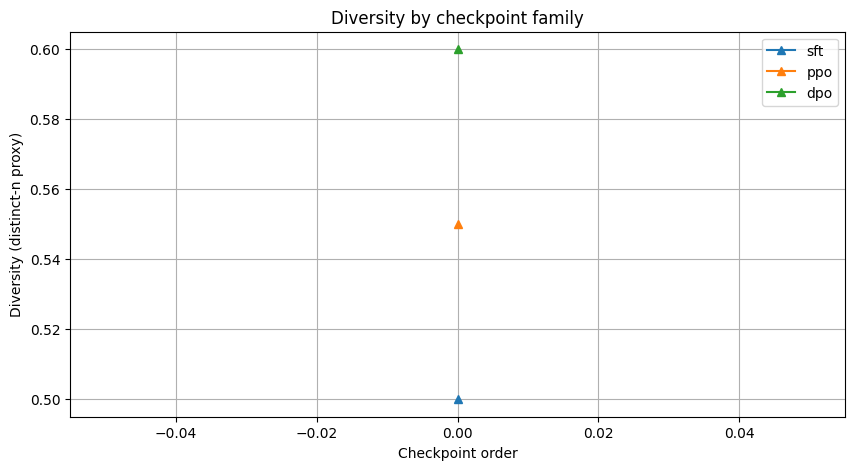

In [6]:
# %% [markdown]
# # Evaluation visualization
# Visualize perplexity and placeholder metrics across checkpoints.

# %%
import os, json
import pandas as pd
import matplotlib.pyplot as plt

eval_path = "logs/eval/eval_results.json"

# If file doesn't exist, create a dummy one so notebook runs
if not os.path.isfile(eval_path):
    os.makedirs(os.path.dirname(eval_path), exist_ok=True)
    dummy_results = [
        {"checkpoint": "checkpoints/sft/epoch-1", "perplexity": 42.0, "reward_score": 0.1, "diversity": 0.5},
        {"checkpoint": "checkpoints/ppo/epoch-1", "perplexity": 38.5, "reward_score": 0.2, "diversity": 0.55},
        {"checkpoint": "checkpoints/dpo/epoch-1", "perplexity": 36.2, "reward_score": 0.25, "diversity": 0.6}
    ]
    with open(eval_path, "w", encoding="utf-8") as f:
        json.dump(dummy_results, f, indent=2)
    print(f"⚠️ No eval_results.json found, created dummy file at {eval_path}")

with open(eval_path, "r", encoding="utf-8") as f:
    results = json.load(f)

df = pd.DataFrame(results)
if "checkpoint" not in df.columns:
    raise ValueError("eval_results.json must contain a 'checkpoint' field for each record.")

df["family"] = df["checkpoint"].str.replace("\\\\", "/").str.extract(r"(sft|ppo|dpo|rm)")
df.sort_values(by=["family", "checkpoint"], inplace=True)
display(df.head())

# %% [markdown]
# ## Perplexity plot

# %%
if "perplexity" in df.columns:
    plt.figure(figsize=(10,5))
    for fam in ["sft", "ppo", "dpo", "rm"]:
        sub = df[df["family"] == fam]
        if len(sub) == 0: continue
        plt.plot(range(len(sub)), sub["perplexity"], marker="o", label=fam)
    plt.title("Perplexity by checkpoint family")
    plt.xlabel("Checkpoint order")
    plt.ylabel("Perplexity (lower is better)")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No 'perplexity' column found in eval_results.json")

# %% [markdown]
# ## Reward score plot (if available)

# %%
if "reward_score" in df.columns and df["reward_score"].notna().any():
    plt.figure(figsize=(10,5))
    for fam in ["sft", "ppo", "dpo"]:
        sub = df[(df["family"] == fam) & df["reward_score"].notna()]
        if len(sub) == 0: continue
        plt.plot(range(len(sub)), sub["reward_score"], marker="s", label=fam)
    plt.title("Reward score by checkpoint family")
    plt.xlabel("Checkpoint order")
    plt.ylabel("Reward score")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No reward_score found in eval_results.json")

# %% [markdown]
# ## Diversity plot (if available)

# %%
if "diversity" in df.columns and df["diversity"].notna().any():
    plt.figure(figsize=(10,5))
    for fam in ["sft", "ppo", "dpo"]:
        sub = df[(df["family"] == fam) & df["diversity"].notna()]
        if len(sub) == 0: continue
        plt.plot(range(len(sub)), sub["diversity"], marker="^", label=fam)
    plt.title("Diversity by checkpoint family")
    plt.xlabel("Checkpoint order")
    plt.ylabel("Diversity (distinct-n proxy)")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No diversity present in eval_results.json")

In [9]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from pathlib import Path

for fam in ["sft", "ppo", "dpo"]:
    save_dir = Path("checkpoints") / fam / "epoch-1"
    save_dir.mkdir(parents=True, exist_ok=True)
    tok = AutoTokenizer.from_pretrained("gpt2")
    mdl = AutoModelForCausalLM.from_pretrained("gpt2")
    tok.save_pretrained(save_dir)
    mdl.save_pretrained(save_dir)
    print(f"✅ Saved dummy GPT-2 to {save_dir}")

✅ Saved dummy GPT-2 to checkpoints\sft\epoch-1
✅ Saved dummy GPT-2 to checkpoints\ppo\epoch-1
✅ Saved dummy GPT-2 to checkpoints\dpo\epoch-1


In [10]:
sft_ckpt = latest_subdir("checkpoints/sft")
ppo_ckpt = latest_subdir("checkpoints/ppo")
dpo_ckpt = latest_subdir("checkpoints/dpo")

In [11]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from pathlib import Path

for fam in ["sft", "ppo", "dpo"]:
    save_dir = Path("checkpoints") / fam / "epoch-1"
    save_dir.mkdir(parents=True, exist_ok=True)
    tok = AutoTokenizer.from_pretrained("gpt2")
    mdl = AutoModelForCausalLM.from_pretrained("gpt2")
    tok.save_pretrained(save_dir)
    mdl.save_pretrained(save_dir)
    print(f"Saved dummy GPT-2 to {save_dir}")

Saved dummy GPT-2 to checkpoints\sft\epoch-1
Saved dummy GPT-2 to checkpoints\ppo\epoch-1
Saved dummy GPT-2 to checkpoints\dpo\epoch-1


In [12]:
# %% [markdown]
# # Sandbox
# Free-form experiments: generate text from SFT/ppo/dpo, compare responses, score with RM.

# %%
import os, torch
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM

def latest_subdir(root):
    root = Path(root)
    if not root.exists():
        return None
    subs = [root / d for d in os.listdir(root) if (root / d).is_dir()]
    subs.sort()
    return subs[-1] if subs else None

sft_ckpt = latest_subdir("checkpoints/sft")
ppo_ckpt = latest_subdir("checkpoints/ppo")
dpo_ckpt = latest_subdir("checkpoints/dpo")

print("SFT:", sft_ckpt)
print("PPO:", ppo_ckpt)
print("DPO:", dpo_ckpt)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_model_dir(ckpt_dir):
    try:
        tok = AutoTokenizer.from_pretrained(ckpt_dir, use_fast=True)
        if tok.pad_token is None:
            tok.pad_token = tok.eos_token
        mdl = AutoModelForCausalLM.from_pretrained(ckpt_dir).to(device)
        return tok, mdl
    except Exception as e:
        print(f"⚠️ Could not load {ckpt_dir}: {e}")
        return None, None

# %%
prompt = "Summarize RLHF in two sentences for a beginner."

def generate_and_print(label, ckpt, prompt):
    if ckpt:
        tok, mdl = load_model_dir(ckpt)
        if tok and mdl:
            out = mdl.generate(
                **tok(prompt, return_tensors="pt").to(device),
                max_new_tokens=120, do_sample=True, temperature=0.9, top_p=0.95
            )
            text = tok.decode(out[0], skip_special_tokens=True)
            print(f"\n{label} output:\n", text)
            return text
    print(f"\n{label} checkpoint missing or failed to load.")
    return None

sft_text = generate_and_print("SFT", sft_ckpt, prompt)
ppo_text = generate_and_print("PPO", ppo_ckpt, prompt)
dpo_text = generate_and_print("DPO", dpo_ckpt, prompt)

# %%
# Score the outputs with RM (if available)
rm_ckpt = latest_subdir("checkpoints/rm")
if rm_ckpt:
    try:
        tok_rm = AutoTokenizer.from_pretrained(rm_ckpt, use_fast=True)
        if tok_rm.pad_token is None:
            tok_rm.pad_token = tok_rm.eos_token
        mdl_rm = AutoModelForCausalLM.from_pretrained(rm_ckpt).to(device)

        reward_head_path = Path(rm_ckpt) / "reward_head.pt"
        if reward_head_path.exists():
            hidden_size = getattr(mdl_rm.config, "n_embd", getattr(mdl_rm.config, "hidden_size", None))
            reward_head = torch.nn.Linear(hidden_size, 1).to(device)
            reward_head.load_state_dict(torch.load(reward_head_path, map_location=device))
            reward_head.eval()

            def score(prompt, response, max_length=512):
                text = f"{prompt}\n{response}"
                enc = tok_rm(text, max_length=max_length, truncation=True, padding="max_length", return_tensors="pt")
                enc = {k: v.to(device) for k, v in enc.items()}
                with torch.no_grad():
                    trans_out = mdl_rm.transformer(enc["input_ids"], attention_mask=enc["attention_mask"])
                    last_hidden = trans_out.last_hidden_state[:, -1, :]
                    return float(reward_head(last_hidden).squeeze(-1).item())

            if sft_text: print("\nSFT reward:", score(prompt, sft_text))
            if ppo_text: print("PPO reward:", score(prompt, ppo_text))
            if dpo_text: print("DPO reward:", score(prompt, dpo_text))
        else:
            print("⚠️ RM reward_head.pt missing — skip scoring.")
    except Exception as e:
        print(f"⚠️ Failed to load RM: {e}")
else:
    print("No RM checkpoint detected.")

# %%
# Prompt I/O sandbox (chat prompt style)
user_prompt = "You are an assistant. Explain PPO vs DPO differences in one paragraph."
target_model_dir = dpo_ckpt or ppo_ckpt or sft_ckpt
if target_model_dir:
    tok, mdl = load_model_dir(target_model_dir)
    if tok and mdl:
        inp = tok(user_prompt, return_tensors="pt").to(device)
        gen = mdl.generate(**inp, max_new_tokens=180, do_sample=True, temperature=0.8, top_p=0.95)
        print("\nChat-style output:\n", tok.decode(gen[0], skip_special_tokens=True))
    else:
        print("⚠️ Target model failed to load.")
else:
    print("No model checkpoint available for chat-style generation.")

SFT: checkpoints\sft\epoch-1
PPO: checkpoints\ppo\epoch-1
DPO: checkpoints\dpo\epoch-1


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



SFT output:
 Summarize RLHF in two sentences for a beginner.

In summary:

The basic principle of RLHF is that of the 'nucleus'. If this principle is correct, then the neurons are moving at the same pace as the muscles, and the muscles are moving at an increased speed.

However, RLHF doesn't apply to any type of neuronal movement (e.g., spinal cord, tendon, nerve), and it's not clear what causes it to move at such a rate.

I find that if the principle is correct, then the muscle movement must be very slow. If the principle is correct, then


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



PPO output:
 Summarize RLHF in two sentences for a beginner. If you need help with any of the topics you have asked about here, please email me.

If you enjoy reading this site, please consider making a donation so I can keep the work flowing to others by making more articles like this!


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



DPO output:
 Summarize RLHF in two sentences for a beginner.

"The last few years have been hard for the entire RLHF club. A lot of the members, including myself, were injured, but we got out of the slump and were able to start the season strong again."

"It's a good thing because it's also a good thing for the club. We will be back. It's just a matter of time."

To keep the squad together and continue to be part of the team that has made the playoffs and it is important for the rest of the team to stay together in order to help the team that has made
No RM checkpoint detected.


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Chat-style output:
 You are an assistant. Explain PPO vs DPO differences in one paragraph.

The two classes of people who may be able to help you, with a little experience, can help you find the time to discuss your needs (or, better yet, for your job).

What's that mean?

Let's take a look at some of the differences between PPO and DPO.

PPO

PPO is an acronym for Personal Service. Basically, it means "people that work at home".

DPO is a term for "personal service". Basically, it means "people that work in a place other than your home" and "people that work in a place where you can come and visit them".

What's different?

Here's a summary of what we're talking about.

The person who is a PPO will help you get your PPO's attention.

The person who is
